In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
import gwsurrogate as gws
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

/home/giacomo/Thesis/Entropy-conjecture/.venv/lib/python3.12/site-packages/gwtools/const.py:52: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


lal.MSUN_SI != Msun


In [3]:
# Loading the model 

sur = gws.LoadSurrogate('NRSur7dq4')

Loaded NRSur7dq4 model


In [ ]:
# function that evolves the system, calculates radiated fluxes, and extracts the r/M orbital separation
    
def simulate_conjecture(q_input, chi1_vec, chi2_vec):

    if q_input < 1.0:
        q = 1.0 / q_input
        chiA_vec = np.array(chi2_vec)
        chiB_vec = np.array(chi1_vec)
    else:
        q = q_input
        chiA_vec = np.array(chi1_vec)
        chiB_vec = np.array(chi2_vec)
        
    t, h, dyn = sur(q, chiA_vec, chiB_vec, dt=0.1, f_low=0.01)
    

    h22 = h[(2, 2)]
    phase_22 = np.unwrap(np.angle(h22))
    omega_22 = np.gradient(phase_22, t)
    omega_orb = np.abs(omega_22) / 2.0
    r_inst = omega_orb**(-2.0 / 3.0)
    

    E_dot = np.zeros_like(t)
    for (l, m), h_lm in h.items():
        h_dot = np.gradient(h_lm, t)
        E_dot += np.abs(h_dot)**2
    E_dot /= (16.0 * np.pi)
    
    J_dot = E_dot / omega_orb
    E_rad = cumulative_trapezoid(E_dot, t, initial=0)
    J_rad = cumulative_trapezoid(J_dot, t, initial=0)
    
  
    m1 = 1.0 / (1.0 + q) 
    m2 = q / (1.0 + q)
    eta = m1 * m2
    
    v0 = omega_orb[0]**(1.0/3.0)
    M_init = 1.0 - (eta / 2.0) * v0**2 
    L_mag_0 = eta / v0
    
    J_vec_0 = np.array([0, 0, L_mag_0]) + (m1**2)*chiA_vec + (m2**2)*chiB_vec
    J_init = np.linalg.norm(J_vec_0)
     

    M_inst = M_init - E_rad
    J_inst = J_init - J_rad
    a_inst = J_inst / (M_inst**2)
    
    valid = a_inst <= 1.0
    
    if not np.any(valid):
        return None
    
    t_valid = t[valid]
    a_valid = a_inst[valid]
    M_valid = M_inst[valid]
    r_valid = r_inst[valid]
    
    root = np.sqrt(1.0 - a_valid**2)
    S_Kerr = 2.0 * np.pi * (M_valid**2) * (1.0 + root)
    S_norm = S_Kerr / (4.0 * np.pi * 1.0**2)
    
    return {
        't': t_valid, 
        'a_inst': a_valid, 
        'S_norm': S_norm, 
        'r': r_valid
    }

In [43]:
# function to visualize the evolution

def plot_surrogate_conjecture_final(res):

    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams.update({'font.size': 14, 'font.family': 'serif'})

    if res is None: return
    t = res['t']
    a_inst = res['a_inst']
    S_norm = res['S_norm']
    r_raw = res['r']
    
    r_fixed = np.minimum.accumulate(r_raw)
    
    max_idx = np.argmax(S_norm)
    S_max = S_norm[max_idx]
    a_max = a_inst[max_idx]
    r_max = r_fixed[max_idx]
    
    merger_idx = np.argmin(np.abs(t))
    S_merg = S_norm[merger_idx]
    a_merg = a_inst[merger_idx]
    r_merg = r_fixed[merger_idx]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Graph 1
    sc1 = ax1.scatter(a_inst, S_norm, c=r_fixed, cmap='viridis_r', s=15, alpha=0.8)
    ax1.plot(a_max, S_max, '*', markersize=15, color='#e7298a', label='Entropy Peak', zorder=5)
    ax1.plot(a_merg, S_merg, 'X', markersize=12, color='black', label='Merger ($t=0$)', zorder=6)
    ax1.set_xlabel(r' $ J/M^2$')
    ax1.set_ylabel(r'$S_{Kerr} / (4\pi M_{tot}^2 / \hbar)$')
    ax1.legend(loc='lower left')
    plt.colorbar(sc1, ax=ax1, label=r'Separation $r/M$')
    ax1.set_title('Kerr State Mapping')

    # Graph 2
    ax2.plot(r_fixed, S_norm, color='#2c7bb6', lw=2.5)
    ax2.plot(r_max, S_max, '*', markersize=15, color='#e7298a', label='Entropy Peak', zorder=5)
    ax2.plot(r_merg, S_merg, 'X', markersize=12, color='black', label='Merger ($t=0$)', zorder=6)
    ax2.vlines(r_max, 0.5, S_max, colors='#e7298a', linestyles='--', alpha=0.5)
    ax2.vlines(r_merg, 0.5, S_merg, colors='black', linestyles='--', alpha=0.5)
    ax2.set_xlabel(r'$r/M$')
    ax2.set_ylabel(r'$S_{Kerr} / (4\pi M_{tot}^2 / \hbar)$')
    ax2.set_xlim(max(r_fixed), min(r_fixed)) 
    ax2.legend(loc='lower left')
    ax2.set_title('Entropy Evolution')
    
    plt.tight_layout()
    plt.show()

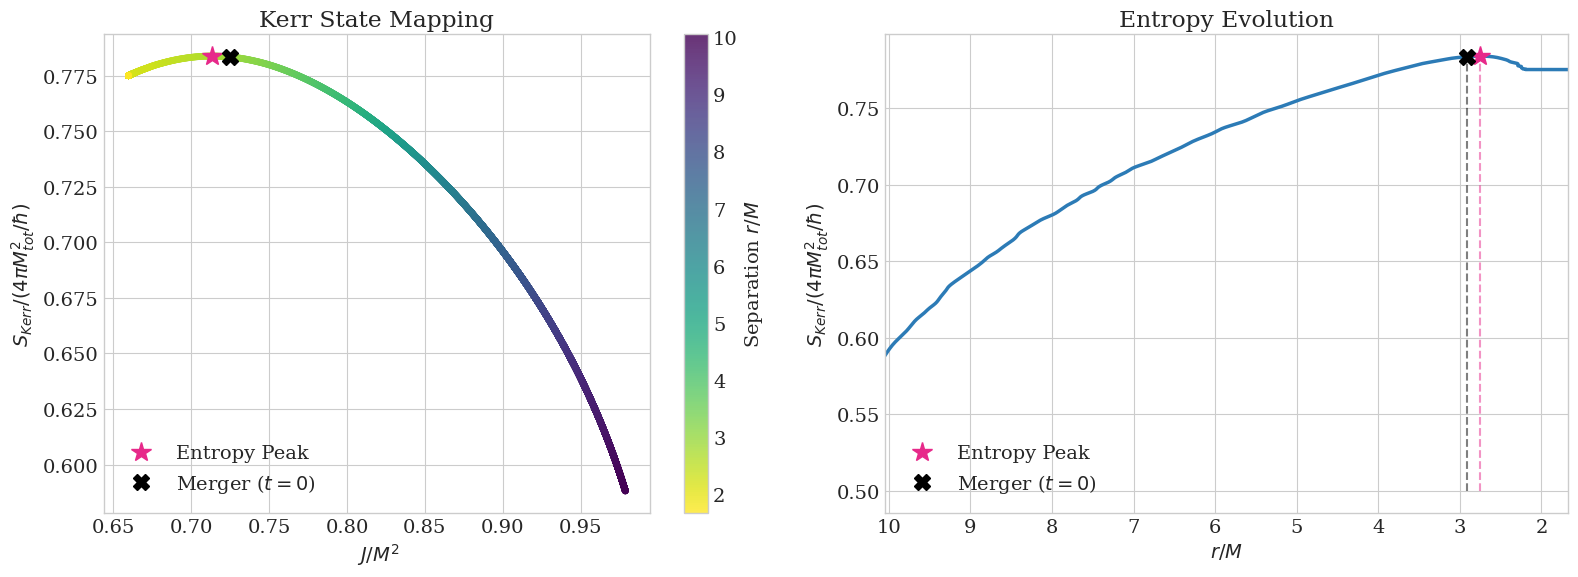

In [44]:
res = simulate_conjecture(q_input=1.3, chi1_vec=[0.2, 0.2, 0.3], chi2_vec=[0.5, 0.1, 0.3])
plot_surrogate_conjecture_final(res)